In [1]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_cn7
from common.train_test_split import split_data
from common.model_composition import model_composition

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_cn7 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_cn7.csv")

In [3]:
X_cn7, y_cn7 = preprocessing_cn7(train_cn7)

print("X shape:", X_cn7.shape)
print("y shape:", y_cn7.shape)

X shape: (1211, 23)
y shape: (1211,)


### OOF 예측확률 생성

> threshold 하나를 정해야 하므로 반복 CV 대신 각 샘플이 정확히 한 번 validation이 되는 StratifiedKFold를 사용

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_threshold = LogisticRegression(
    max_iter=1000,
    random_state=42
)

oof_prob = cross_val_predict(
    model_threshold,
    X_cn7,
    y_cn7,
    cv=cv_threshold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

### Threshold별 성능 비교

In [5]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.05):

    y_pred = (oof_prob >= threshold).astype(int)

    cm = confusion_matrix(y_cn7, y_pred)
    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_cn7, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_cn7, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_cn7, y_pred, zero_division=0
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.05,0.175439,0.588235,0.270270,10,47,7,1147
1,0.10,0.250000,0.470588,0.326531,8,24,9,1170
2,0.15,0.285714,0.352941,0.315789,6,15,11,1179
3,0.20,0.375000,0.352941,0.363636,6,10,11,1184
4,0.25,0.400000,0.352941,0.375000,6,9,11,1185
5,0.30,0.461538,0.352941,0.400000,6,7,11,1187
6,0.35,0.666667,0.352941,0.461538,6,3,11,1191
7,0.40,0.666667,0.352941,0.461538,6,3,11,1191
8,0.45,0.857143,0.352941,0.500000,6,1,11,1193
9,0.50,1.000000,0.352941,0.521739,6,0,11,1194


In [6]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

display(best_row)

Threshold       0.500000
Precision       1.000000
Recall          0.352941
F1              0.521739
TP              6.000000
FP              0.000000
FN             11.000000
TN           1194.000000
Name: 9, dtype: float64

In [7]:
display(threshold_df)

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.05,0.175439,0.588235,0.270270,10,47,7,1147
1,0.10,0.250000,0.470588,0.326531,8,24,9,1170
2,0.15,0.285714,0.352941,0.315789,6,15,11,1179
3,0.20,0.375000,0.352941,0.363636,6,10,11,1184
4,0.25,0.400000,0.352941,0.375000,6,9,11,1185
5,0.30,0.461538,0.352941,0.400000,6,7,11,1187
6,0.35,0.666667,0.352941,0.461538,6,3,11,1191
7,0.40,0.666667,0.352941,0.461538,6,3,11,1191
8,0.45,0.857143,0.352941,0.500000,6,1,11,1193
9,0.50,1.000000,0.352941,0.521739,6,0,11,1194


Threshold 감소를 통해 불량 탐지율을 높일 수 있었으나, Recall 향상에 비해 False Positive가 빠르게 증가하는 trade-off가 확인되었다. 특히 Threshold 0.15~0.45에서는 Recall 향상 없이 오탐만 증가했으며, F1 기준으로는 기본 Threshold 0.50이 가장 높은 성능을 기록하였다. 따라서 CN7 Logistic Regression에서는 임계값 조정보다 클래스 불균형 처리 방식과 모델 자체의 판별 성능 개선이 더 중요한 것으로 판단하였다.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import numpy as np
import pandas as pd


# 1. 모델 정의
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    
    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),
    
    "XGBoost": XGBClassifier(
        random_state=42
    ),
    
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}


# 2. Threshold 검증용 CV
cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# 3. Threshold 후보
thresholds = np.arange(0.05, 0.51, 0.05)

threshold_all_results = []


# 4. 모델별 OOF 확률 + Threshold 비교
for name, model in models.items():

    oof_prob = cross_val_predict(
        model,
        X_cn7,
        y_cn7,
        cv=cv_threshold,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    for threshold in thresholds:

        y_pred = (oof_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_cn7,
            y_pred
        ).ravel()

        threshold_all_results.append({
            "Model": name,
            "Threshold": round(threshold, 2),
            "Precision": precision_score(
                y_cn7,
                y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_cn7,
                y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_cn7,
                y_pred,
                zero_division=0
            ),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })


threshold_all_df = pd.DataFrame(threshold_all_results)

display(threshold_all_df)

,Model,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,Logistic Regression,0.05,0.175439,0.588235,0.270270,10,47,7,1147
1,Logistic Regression,0.10,0.250000,0.470588,0.326531,8,24,9,1170
2,Logistic Regression,0.15,0.285714,0.352941,0.315789,6,15,11,1179
3,Logistic Regression,0.20,0.375000,0.352941,0.363636,6,10,11,1184
4,Logistic Regression,0.25,0.400000,0.352941,0.375000,6,9,11,1185
5,Logistic Regression,0.30,0.461538,0.352941,0.400000,6,7,11,1187
6,Logistic Regression,0.35,0.666667,0.352941,0.461538,6,3,11,1191
7,Logistic Regression,0.40,0.666667,0.352941,0.461538,6,3,11,1191
8,Logistic Regression,0.45,0.857143,0.352941,0.500000,6,1,11,1193
9,Logistic Regression,0.50,1.000000,0.352941,0.521739,6,0,11,1194


In [11]:
best_threshold_df = (
    threshold_all_df
    .loc[
        threshold_all_df
        .groupby("Model")["F1"]
        .idxmax()
    ]
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(best_threshold_df)

,Model,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,Logistic Regression,0.50,1.000,0.352941,0.521739,6,0,11,1194
1,CatBoost,0.10,0.375,0.352941,0.363636,6,10,11,1184
2,LightGBM,0.05,0.375,0.352941,0.363636,6,10,11,1184
3,Random Forest,0.35,0.375,0.352941,0.363636,6,10,11,1184
4,XGBoost,0.10,0.375,0.352941,0.363636,6,10,11,1184


모델별 Threshold를 0.05~0.50 범위에서 비교한 결과, Logistic Regression에서만 Threshold 감소에 따른 실질적인 Recall 향상이 확인되었다. 그러나 Recall 증가와 함께 False Positive가 크게 증가하여 F1 기준으로는 기본 Threshold 0.50이 가장 우수하였다. Random Forest는 0.05에서 Recall이 소폭 증가했으나 오탐이 급증하였고, LightGBM·XGBoost·CatBoost에서는 Threshold 조정에 따른 Recall 개선이 확인되지 않았다. 따라서 CN7에서는 Threshold 조정만으로 불량 탐지 성능을 개선하는 데 한계가 있는 것으로 나타났다.

### 5개 모델의 OOF 예측확률 분포 확인


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import pandas as pd

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probs = {}

for name, model in models.items():

    prob = cross_val_predict(
        model,
        X_cn7,
        y_cn7,
        cv=cv_threshold,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_probs[name] = prob

In [13]:
prob_summary = []

for name, prob in oof_probs.items():

    prob_summary.append({
        "Model": name,
        "Min": prob.min(),
        "Q1": pd.Series(prob).quantile(0.25),
        "Median": pd.Series(prob).median(),
        "Q3": pd.Series(prob).quantile(0.75),
        "Max": prob.max(),
        "0.05~0.50 Count": ((prob >= 0.05) & (prob < 0.50)).sum()
    })

prob_summary_df = pd.DataFrame(prob_summary)

display(prob_summary_df)

,Model,Min,Q1,Median,Q3,Max,0.05~0.50 Count
0,Logistic Regression,2.986669e-06,0.000150,0.000595,0.003517,0.984080,51
1,Random Forest,0.000000e+00,0.000000,0.000000,0.000000,0.970000,44
2,LightGBM,8.112360e-07,0.000003,0.000006,0.000027,0.998882,0
3,XGBoost,1.658688e-05,0.000087,0.000156,0.000495,0.962137,3
4,CatBoost,6.480978e-05,0.000170,0.000306,0.001277,0.980738,4


In [14]:
class_prob_summary = []

for name, prob in oof_probs.items():

    for target in [0, 1]:

        target_prob = prob[y_cn7.to_numpy() == target]

        class_prob_summary.append({
            "Model": name,
            "Target": target,
            "Count": len(target_prob),
            "Mean Prob": target_prob.mean(),
            "Median Prob": pd.Series(target_prob).median(),
            "Min Prob": target_prob.min(),
            "Max Prob": target_prob.max()
        })

class_prob_summary_df = pd.DataFrame(class_prob_summary)

display(class_prob_summary_df)

,Model,Target,Count,Mean Prob,Median Prob,Min Prob,Max Prob
0,Logistic Regression,0,1194,0.009234,0.000577,2.986669e-06,0.467578
1,Logistic Regression,1,17,0.372285,0.080410,7.960705e-03,0.984080
2,Random Forest,0,1194,0.012277,0.000000,0.000000e+00,0.708333
3,Random Forest,1,17,0.332559,0.036667,0.000000e+00,0.970000
4,LightGBM,0,1194,0.008511,0.000006,8.112360e-07,0.998882
5,LightGBM,1,17,0.352067,0.001507,4.865458e-05,0.998503
6,XGBoost,0,1194,0.008775,0.000154,1.658688e-05,0.940887
7,XGBoost,1,17,0.337579,0.018844,4.381926e-04,0.962137
8,CatBoost,0,1194,0.009118,0.000297,6.480978e-05,0.930332
9,CatBoost,1,17,0.348388,0.011544,2.063837e-03,0.980738


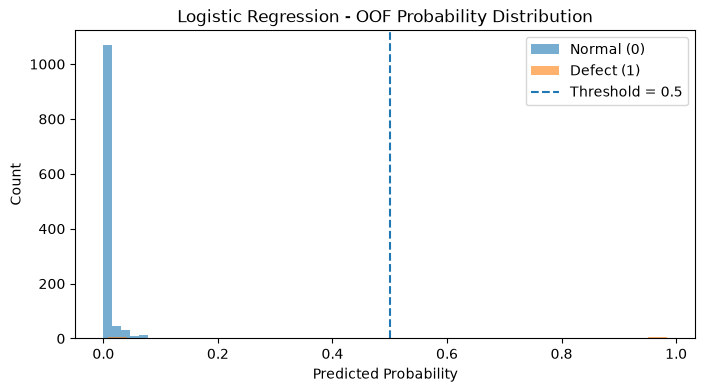

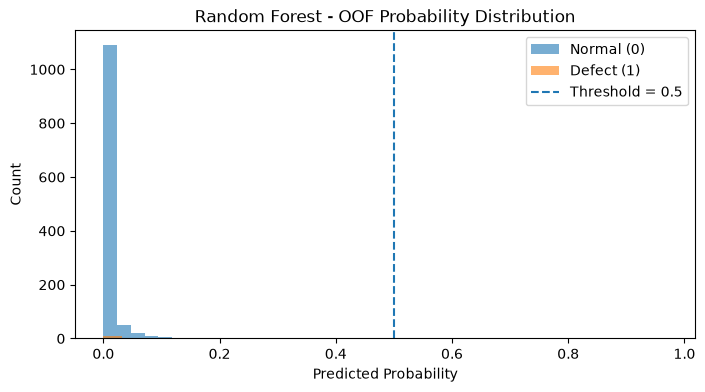

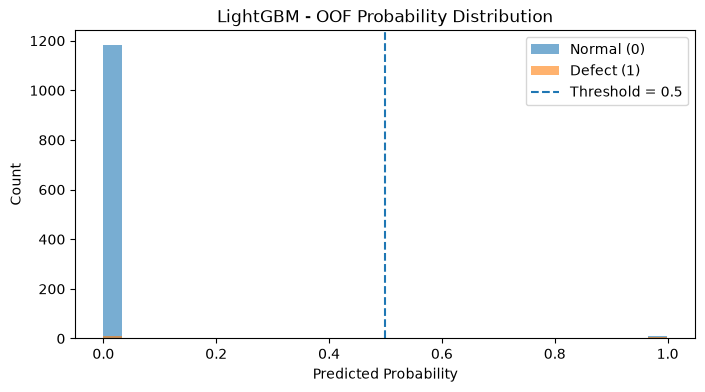

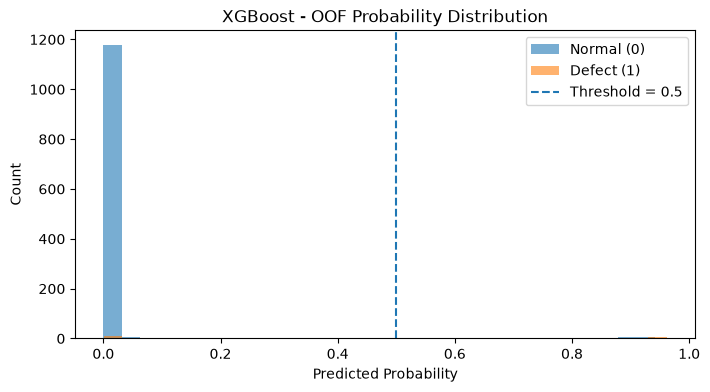

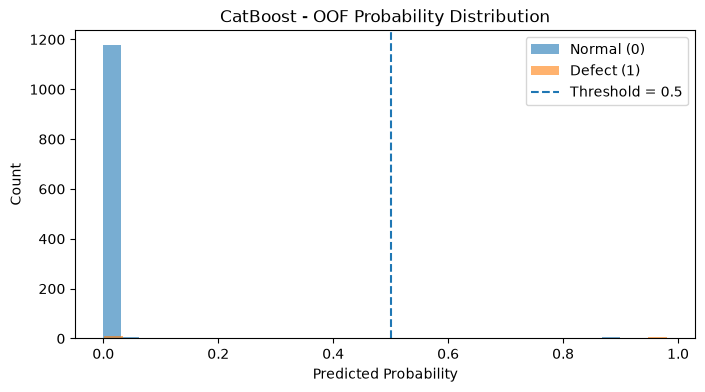

In [15]:
import matplotlib.pyplot as plt

for name, prob in oof_probs.items():

    plt.figure(figsize=(8, 4))

    plt.hist(
        prob[y_cn7.to_numpy() == 0],
        bins=30,
        alpha=0.6,
        label="Normal (0)"
    )

    plt.hist(
        prob[y_cn7.to_numpy() == 1],
        bins=30,
        alpha=0.6,
        label="Defect (1)"
    )

    plt.axvline(
        0.5,
        linestyle="--",
        label="Threshold = 0.5"
    )

    plt.title(f"{name} - OOF Probability Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

모든 모델에서 실제 불량의 평균 예측확률이 정상보다 높게 나타나 불량 관련 패턴을 일정 수준 학습한 것으로 확인되었다. 그러나 불량의 평균확률과 중앙값 간 차이가 크게 나타났으며, 특히 Tree 기반 모델에서는 일부 불량에 매우 높은 확률을 부여하는 반면 다수의 불량에는 낮은 확률을 부여하였다. 또한 일부 정상 데이터에도 높은 불량확률이 관찰되어 정상·불량 확률 분포가 완전히 분리되지 않았다. Logistic Regression은 정상 데이터의 최대 불량확률이 0.4676으로 나타나 Threshold 0.5에서 FP가 발생하지 않았으며, 다른 모델보다 Threshold 조정에 따른 변화가 상대적으로 명확하게 나타났다.